# Mini Project — Customer Churn Prediction

In [11]:
from sklearn.datasets import load_iris
import numpy as np
import pandas as pd 
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier


In [17]:
df = pd.read_csv("./Datasets/customer_churn_data.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,Male,0,No,Yes,23,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,No
1,CUST0001,Female,0,Yes,No,43,No,No phone service,DSL,Yes,...,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,Yes
2,CUST0002,Male,1,No,No,51,Yes,No,DSL,No,...,Yes,Yes,No,No,One year,No,Electronic check,97.33,4963.83,Yes
3,CUST0003,Male,1,No,No,72,Yes,Yes,DSL,Yes,...,Yes,No,No,No,Month-to-month,No,Credit card,101.38,7299.36,No
4,CUST0004,Male,1,No,No,25,Yes,Yes,DSL,No,...,No,Yes,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5875,CUST5875,Male,0,Yes,Yes,71,Yes,No,DSL,Yes,...,No,Yes,No,No,Month-to-month,Yes,Mailed check,74.21,5268.91,No
5876,CUST5876,Male,0,No,No,22,Yes,Yes,DSL,No,...,Yes,Yes,No,Yes,One year,No,Mailed check,65.43,1439.46,Yes
5877,CUST5877,Female,0,No,No,68,No,No phone service,Fiber optic,Yes,...,Yes,Yes,Yes,No,One year,Yes,Bank transfer,59.78,4065.04,No
5878,CUST5878,Female,0,Yes,Yes,14,No,No phone service,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Mailed check,91.88,1286.32,No


In [3]:
df.shape

(5880, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5880 non-null   str    
 1   gender            5880 non-null   str    
 2   SeniorCitizen     5880 non-null   int64  
 3   Partner           5880 non-null   str    
 4   Dependents        5880 non-null   str    
 5   tenure            5880 non-null   int64  
 6   PhoneService      5880 non-null   str    
 7   MultipleLines     5880 non-null   str    
 8   InternetService   5880 non-null   str    
 9   OnlineSecurity    5880 non-null   str    
 10  OnlineBackup      5880 non-null   str    
 11  DeviceProtection  5880 non-null   str    
 12  TechSupport       5880 non-null   str    
 13  StreamingTV       5880 non-null   str    
 14  StreamingMovies   5880 non-null   str    
 15  Contract          5880 non-null   str    
 16  PaperlessBilling  5880 non-null   str    
 17  Paymen

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df["Churn"].value_counts()

Churn
No     2982
Yes    2898
Name: count, dtype: int64

In [18]:
le = LabelEncoder()

data = ["gender", "Churn", "PaperlessBilling", "Contract","PhoneService","Dependents","Partner","OnlineSecurity","TechSupport","InternetService","PaymentMethod"]
for col in data:
    df[col] = le.fit_transform(df[col])

df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,1,0,0,1,23,0,No phone service,2,1,...,No internet service,1,No internet service,No internet service,0,1,0,49.85,1146.55,0
1,CUST0001,0,0,1,0,43,0,No phone service,0,2,...,Yes,0,Yes,No,0,0,3,100.70,4330.10,1
2,CUST0002,1,1,0,0,51,1,No,0,0,...,Yes,2,No,No,1,0,2,97.33,4963.83,1
3,CUST0003,1,1,0,0,72,1,Yes,0,2,...,Yes,0,No,No,0,0,1,101.38,7299.36,0
4,CUST0004,1,1,0,0,25,1,Yes,0,0,...,No,2,No,Yes,0,0,2,52.22,1305.50,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5875,CUST5875,1,0,1,1,71,1,No,0,2,...,No,2,No,No,0,1,3,74.21,5268.91,0
5876,CUST5876,1,0,0,0,22,1,Yes,0,0,...,Yes,2,No,Yes,1,0,3,65.43,1439.46,1
5877,CUST5877,0,0,0,0,68,0,No phone service,1,2,...,Yes,2,Yes,No,1,1,0,59.78,4065.04,0
5878,CUST5878,0,0,1,1,14,0,No phone service,1,2,...,Yes,2,Yes,Yes,0,1,3,91.88,1286.32,0


In [19]:
X = df[['gender','SeniorCitizen','Partner','Dependents','tenure','PhoneService','Contract','PaperlessBilling','MonthlyCharges','TotalCharges',"OnlineSecurity","TechSupport","InternetService","PaymentMethod"]]
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

In [20]:
model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42,
    max_depth=3
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.4872448979591837


In [21]:
y.value_counts(normalize=True)

Churn
0    0.507143
1    0.492857
Name: proportion, dtype: float64

In [22]:
model = DecisionTreeClassifier()
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid.fit(X_train, y_train)

# Best Results
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_*100)

# Test Accuracy
print("Test Accuracy:", grid.score(X_test, y_test))

Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV Score: 51.133546300202916
Test Accuracy: 0.5093537414965986


In [23]:
best_tree = grid.best_estimator_

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_tree.feature_importances_
})

print(
    importance.sort_values(
        "Importance",
        ascending=False
    )
)

             Feature  Importance
8     MonthlyCharges    0.271143
9       TotalCharges    0.212695
4             tenure    0.145539
13     PaymentMethod    0.070514
6           Contract    0.067519
0             gender    0.033008
11       TechSupport    0.030804
12   InternetService    0.028673
5       PhoneService    0.028416
10    OnlineSecurity    0.027351
7   PaperlessBilling    0.025807
1      SeniorCitizen    0.024880
2            Partner    0.019488
3         Dependents    0.014163


In [24]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train, y_train)

print(
    accuracy_score(
        y_test,
        dummy.predict(X_test)
    )
)

0.5085034013605442


In [25]:
print(df.shape)

print(df["Churn"].value_counts())

print(df["Churn"].value_counts(normalize=True))

print(df.head())

(5880, 21)
Churn
0    2982
1    2898
Name: count, dtype: int64
Churn
0    0.507143
1    0.492857
Name: proportion, dtype: float64
  customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0   CUST0000       1              0        0           1      23   
1   CUST0001       0              0        1           0      43   
2   CUST0002       1              1        0           0      51   
3   CUST0003       1              1        0           0      72   
4   CUST0004       1              1        0           0      25   

   PhoneService     MultipleLines  InternetService  OnlineSecurity  ...  \
0             0  No phone service                2               1  ...   
1             0  No phone service                0               2  ...   
2             1                No                0               0  ...   
3             1               Yes                0               2  ...   
4             1               Yes                0               0  ...   

      Devi

In [26]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# =========================
# LOAD DATASET
# =========================

df = pd.read_csv("./Datasets/customer_churn_data.csv")

print("Shape:", df.shape)

# =========================
# DATA CLEANING
# =========================

# Remove customerID if present
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Convert TotalCharges to numeric
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(
        df['TotalCharges'],
        errors='coerce'
    )

    df['TotalCharges'].fillna(
        df['TotalCharges'].median(),
        inplace=True
    )

# =========================
# ENCODE CATEGORICAL COLUMNS
# =========================

categorical_cols = df.select_dtypes(
    include=['object']
).columns

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# =========================
# TARGET DISTRIBUTION
# =========================

print("\nTarget Distribution:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

# =========================
# FEATURES / TARGET
# =========================

X = df.drop('Churn', axis=1)
y = df['Churn']

# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# GRID SEARCH
# =========================

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

tree = DecisionTreeClassifier(
    random_state=42
)

grid = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

# =========================
# BEST MODEL
# =========================

best_model = grid.best_estimator_

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest CV Accuracy:")
print(round(grid.best_score_ * 100, 2))

# =========================
# PREDICTIONS
# =========================

train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

# =========================
# ACCURACY
# =========================

train_acc = accuracy_score(
    y_train,
    train_pred
)

test_acc = accuracy_score(
    y_test,
    test_pred
)

print("\nTrain Accuracy:", round(train_acc * 100, 2))
print("Test Accuracy :", round(test_acc * 100, 2))

# =========================
# CLASSIFICATION REPORT
# =========================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_pred
    )
)

# =========================
# CONFUSION MATRIX
# =========================

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        test_pred
    )
)

# =========================
# FEATURE IMPORTANCE
# =========================

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance_df)

# =========================
# TOP 10 FEATURES
# =========================

print("\nTop 10 Features:")
print(importance_df.head(10))

Shape: (5880, 21)

Target Distribution:
Churn
0    2982
1    2898
Name: count, dtype: int64
Churn
0    0.507143
1    0.492857
Name: proportion, dtype: float64


C:\Users\BAHU Computers\AppData\Local\Temp\ipykernel_15340\1680756027.py:36: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(
C:\Users\BAHU Computers\AppData\Local\Temp\ipykernel_15340\1680756027.py:45: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype i


Best Parameters:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best CV Accuracy:
50.98

Train Accuracy: 52.13
Test Accuracy : 49.74

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.17      0.25       596
           1       0.49      0.84      0.62       580

    accuracy                           0.50      1176
   macro avg       0.50      0.50      0.44      1176
weighted avg       0.50      0.50      0.43      1176


Confusion Matrix:
[[ 99 497]
 [ 94 486]]

Feature Importance:
             Feature  Importance
18      TotalCharges    0.776310
11       TechSupport    0.099118
14          Contract    0.087975
17    MonthlyCharges    0.036597
2            Partner    0.000000
0             gender    0.000000
1      SeniorCitizen    0.000000
3         Dependents    0.000000
4             tenure    0.000000
5       PhoneService    0.000000
6      MultipleLines    0.000000
10  DeviceProtect

In [27]:
corr = df.corr(numeric_only=True)

print(
    corr["Churn"]
    .sort_values(ascending=False)
)

Churn               1.000000
Contract            0.016734
DeviceProtection    0.016606
MonthlyCharges      0.014969
TotalCharges        0.014264
OnlineBackup        0.010779
Partner             0.010134
tenure              0.008600
gender              0.008213
InternetService     0.005454
PaymentMethod       0.003928
Dependents          0.001050
PaperlessBilling    0.000437
MultipleLines      -0.000918
OnlineSecurity     -0.004543
SeniorCitizen      -0.004743
StreamingTV        -0.005155
StreamingMovies    -0.009845
TechSupport        -0.014961
PhoneService       -0.018024
Name: Churn, dtype: float64


<Axes: >

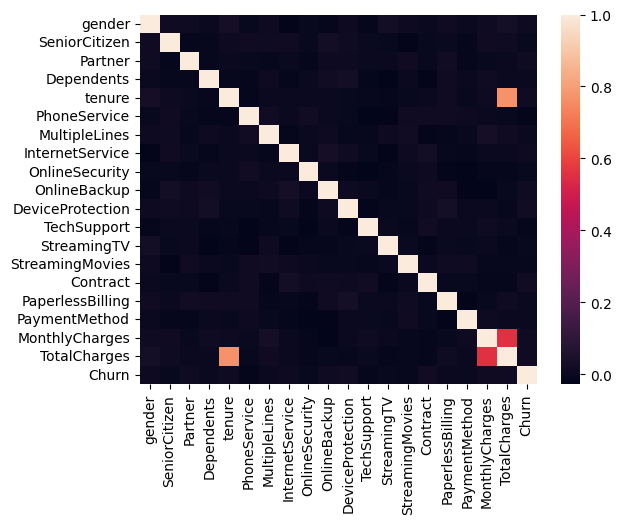

In [28]:
import seaborn as sns
sns.heatmap(corr)

In [29]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000
)

lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print(
    accuracy_score(
        y_test,
        pred
    )
)

0.5


In [30]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score


# Create a list of models to evaluate
models = [
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42))
]

best_model = None
best_accuracy = 0.0

# Iterate over the models and evaluate their performance
for name, model in models:
    # Create a pipeline for each model
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore')),
        ('model', model)
    ])
    
    # Perform cross-validation
    scores = cross_val_score(pipeline, X_train, y_train, cv=5)
    
    # Calculate mean accuracy
    mean_accuracy = scores.mean()
    
    # Fit the pipeline on the training data
    pipeline.fit(X_train, y_train)
    
    # Make predictions on the test data
    y_pred = pipeline.predict(X_test)
    
    # Calculate accuracy score
    accuracy = accuracy_score(y_test, y_pred)
    
    # Print the performance metrics
    print("Model:", name)
    print("Cross-validation Accuracy:", mean_accuracy)
    print("Test Accuracy:", accuracy)
    print()
    
    # Check if the current model has the best accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline

# Retrieve the best model
print("Best Model:", best_model)

Model: Random Forest
Cross-validation Accuracy: 0.4942600673796549
Test Accuracy: 0.5144557823129252

Model: Gradient Boosting
Cross-validation Accuracy: 0.504250118705768
Test Accuracy: 0.5025510204081632

Model: Decision Tree
Cross-validation Accuracy: 0.4914977276324417
Test Accuracy: 0.47874149659863946

Best Model: Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore')),
                ('model', RandomForestClassifier(random_state=42))])
